
---

## Experimentos Realizados

| ID  | Dataset               | Clases                | N    | TARGET | AUC test | F1 test | Comentario |
|-----|-----------------------|-----------------------|------|--------|----------|---------|------------|
| v1  | Kaggle Kepler         | CONFIRMED vs FP       | 5087 | 3197   | 0.65     | 0.57    | Baseline con dataset público |
| v3  | Kepler real (KOI)     | CONFIRMED vs FP       | 300  | 3197   | 0.65     | 0.68    | FP tienen binarias eclipsantes |
| v4b | Kepler real (1001)    | CONFIRMED vs Sin KOI  | 200  | 1001   | 0.59     | 0.64    | Downsampling a 1001 puntos |
| **v5** | **Kepler real grande** | **CONFIRMED vs Sin KOI** | **2800** | **1001** | **0.56** | **0.67** | **Experimento definitivo** |

---

## Conclusiones Científicas

### 1. La curva de luz sola no basta
Con 2800 estrellas reales a 1001 puntos, la SNN colapsa a predecir "planeta"
para todas las muestras (TN=0, FP=280 en test). El AUC de 0.56 está cerca del azar.

### 2. Los tránsitos de CONFIRMED son invisibles tras downsampling
Los tránsitos de planetas confirmados por Kepler tienen profundidades del
**0.1-0.5%**, mientras que las binarias eclipsantes (clase negativa en v3)
tienen profundidades del **3-5%**. Al comprimir 50,000 puntos a 1,001 (factor 50×),
los tránsitos someros caben en menos de 1 punto y se diluyen.

### 3. Sesgo de selección en CONFIRMED
Las estrellas CONFIRMED son estadísticamente **más ruidosas** que las Sin KOI
(std intra-curva 0.0016 vs 0.0013). Esto refleja que las estrellas activas
tienen más probabilidad de tener planetas detectables, no que el ruido sea
la señal.

### 4. La tarea requiere features adicionales
La literatura astronómica moderna (AstroNet, ExoMiner, ExoMiner++) usa:
- **Features de tránsito**: período, duración, profundidad, forma (U vs V)
- **Features estelares**: radio, masa, temperatura, metalicidad
- **Centroide del tránsito**: para descartar binarias de fondo
- **Espectroscopía**: para confirmar la naturaleza del objeto

---

## Aprendizajes Técnicos

### Pipeline de datos
- **lightkurve** para descarga de curvas de luz del archivo MAST
- **astroquery** para consultar catálogos de la NASA Exoplanet Archive
- Preprocessing propio que **preserva tránsitos** (sigma-clipping unilateral)
- **Checkpointing incremental** para descargas largas (2400 estrellas = 4.7 horas)

### Modelado
- **snnTorch** para Redes Neuronales de Impulsos con neuronas LIF
- Arquitectura bioinspirada: Conv1D (lamina→medula) + LIF (lobula)
- **WeightedRandomSampler** para desbalance severo (1:136 en Kaggle)
- Data augmentation con ruido gaussiano (funciona solo con >1000 muestras)

### Errores aprendidos
- El **flatten()** de lightkurve centra las curvas en valores inconsistentes (0, 1, 0.8).
- El **sigma-clipping bilateral** elimina los tránsitos (los confunde con outliers).
- El **downsampling agresivo** (16×-50×) destruye señales débiles.
- El **doble balanceo** (sampler + class weights) causa gradientes inestables.
- **Windows + Jupyter + emojis = UnicodeEncodeError**.

---

## Lo Que Funcionó

- **Descarga incremental con checkpoints** para datasets largos.
- **SNN con Conv1D + LIF** entrena rápido en CPU (1-2 min por 30 épocas).
- **robust_normalize_simple** (mediana + MAD) es estable y robusto.
- **Threshold óptimo** en validación mejora F1 vs usar argmax directo.

## Lo Que No Funcionó

- **Detectar tránsitos someros** con downsampleado agresivo.
- **Distinguir CONFIRMED de FP** sin features adicionales.
- **Augmentation con factor=5** con menos de 100 muestras.
- **Scheduler ReduceLROnPlateau** con patience < 7 (baja LR demasiado pronto).

---

## Próximos Pasos

### Corto plazo
- Probar **features engineered + XGBoost** (enfoque de la industria)
- Considerar **TARGET_LENGTH=201** para preservar tránsitos someros

### Mediano plazo
- **Reto 2: Fulguraciones solares** — problema intrínsecamente temporal donde
  las SNN son competitivas.
- **Reto 3: Evasión de basura espacial** — control reactivo con SNN ligera.

### Largo plazo
- Integrar features astronómicas reales (período, duración, centroide).
- Explorar arquitecturas modernas (Transformers, Graph Neural Networks).

---

## Stack Técnico

- **Python 3.12**
- **PyTorch 2.x** + **snnTorch 1.0**
- **lightkurve** (descarga de curvas de luz)
- **astroquery** (catálogos NASA)
- **scikit-learn** (métricas, split)
- **scipy** (señales)
- **pandas**, **numpy**, **matplotlib**

## Hardware

- CPU: Intel Core i7 8ª generación
- RAM: 20 GB
- GPU: no (entrenamiento en CPU)
- Tiempo total del proyecto: ~40 horas (mayoría en descargas)

---

## Agradecimientos

Este proyecto se desarrolló explorando la frontera entre neurociencia
computacional (conectoma de la mosca *Drosophila*) y astrofísica
(detección de exoplanetas). Aunque el resultado fue negativo, el viaje
produjo infraestructura reutilizable, aprendizajes profundos, y una
mejor comprensión de cuándo las SNN son y no son apropiadas.

> "El éxito consiste en ir de fracaso en fracaso sin perder el entusiasmo."
> — Winston Churchill

---

## Licencia

Este proyecto es de código abierto y está disponible bajo la licencia MIT.

## Contacto

Proyecto desarrollado como exploración personal en la intersección
entre neurociencia, machine learning y astrofísica.
"""

with open('../README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("[OK] README.md creado")
print(f"     Tamaño: {len(readme)} caracteres")
print(f"     Ubicación: ../README.md")

In [1]:
import json
from datetime import datetime

resultados_consolidados = {
    'proyecto': 'Detección de exoplanetas con SNN bioinspirada',
    'fecha_cierre': datetime.now().isoformat(),
    'experimentos': [
        {
            'id': 'v1',
            'dataset': 'Kaggle Kepler',
            'clases': ['CONFIRMED', 'FALSE POSITIVE'],
            'n_total': 5087,
            'target_length': 3197,
            'arquitectura': 'FlyInspiredSNN',
            'params': 189378,
            'epochs': 50,
            'auc_test': None,
            'f1_test': 0.5714,
            'conclusion': 'Baseline. Clase negativa (FP) tiene tránsitos profundos.',
        },
        {
            'id': 'v3',
            'dataset': 'Kepler real (KOI)',
            'clases': ['CONFIRMED', 'FALSE POSITIVE'],
            'n_total': 300,
            'target_length': 3197,
            'arquitectura': 'FlyInspiredSNN',
            'params': 47458,
            'epochs': 50,
            'auc_test': 0.6539,
            'f1_test': 0.6842,
            'conclusion': 'Problema de vetting intrínsecamente difícil.',
        },
        {
            'id': 'v4b',
            'dataset': 'Kepler real',
            'clases': ['CONFIRMED', 'Sin KOI'],
            'n_total': 200,
            'target_length': 1001,
            'arquitectura': 'FlyInspiredSNN',
            'params': 16226,
            'epochs': 30,
            'auc_test': 0.5900,
            'f1_test': 0.6415,
            'conclusion': 'Cambio de clase negativa. Mejora marginal.',
        },
        {
            'id': 'v5',
            'dataset': 'Kepler real grande',
            'clases': ['CONFIRMED', 'Sin KOI'],
            'n_total': 2800,
            'target_length': 1001,
            'arquitectura': 'FlyInspiredSNN',
            'params': 16226,
            'epochs': 30,
            'auc_test': 0.5588,
            'f1_test': 0.6667,
            'conclusion': (
                'Experimento definitivo. El modelo colapsa a predecir "planeta" '
                'para todas las muestras (TN=0, FP=280). El AUC de 0.56 está '
                'cerca del azar. Confirmado: la curva de luz sola no basta.'
            ),
        },
    ],
    'conclusion_global': (
        'La SNN inspirada en el sistema visual de la mosca NO logra distinguir '
        'planetas confirmados de estrellas sin señal usando solo la curva de luz. '
        'El problema requiere features adicionales (período, duración, profundidad, '
        'centroide, espectroscopía) que son estándar en la literatura astronómica.'
    ),
    'aprendizajes_tecnicos': [
        'lightkurve + astroquery para acceso a datos de Kepler',
        'Preprocessing propio que preserva tránsitos (sigma-clipping unilateral)',
        'Checkpointing incremental para descargas largas',
        'SNN con Conv1D + LIF en snnTorch',
        'WeightedRandomSampler para desbalance severo',
    ],
    'limitaciones_identificadas': [
        'Downsampling agresivo destruye tránsitos someros',
        'Sesgo de selección: CONFIRMED son más ruidosas que Sin KOI',
        'Falta de features astronómicas adicionales',
        'SNN no es la arquitectura más adecuada para clasificación de señales débiles',
    ],
    'proximos_pasos': [
        'Probar features engineered + XGBoost',
        'Migrar a problemas intrínsecamente temporales (fulguraciones solares)',
        'Explorar SNN para control reactivo (evasión de debris)',
    ],
}

with open('../outputs/proyecto_resultados.json', 'w', encoding='utf-8') as f:
    json.dump(resultados_consolidados, f, indent=2, ensure_ascii=False)

print("[OK] Resultados consolidados guardados")
print(f"     ../outputs/proyecto_resultados.json")
print(f"     {len(resultados_consolidados['experimentos'])} experimentos registrados")

[OK] Resultados consolidados guardados
     ../outputs/proyecto_resultados.json
     4 experimentos registrados


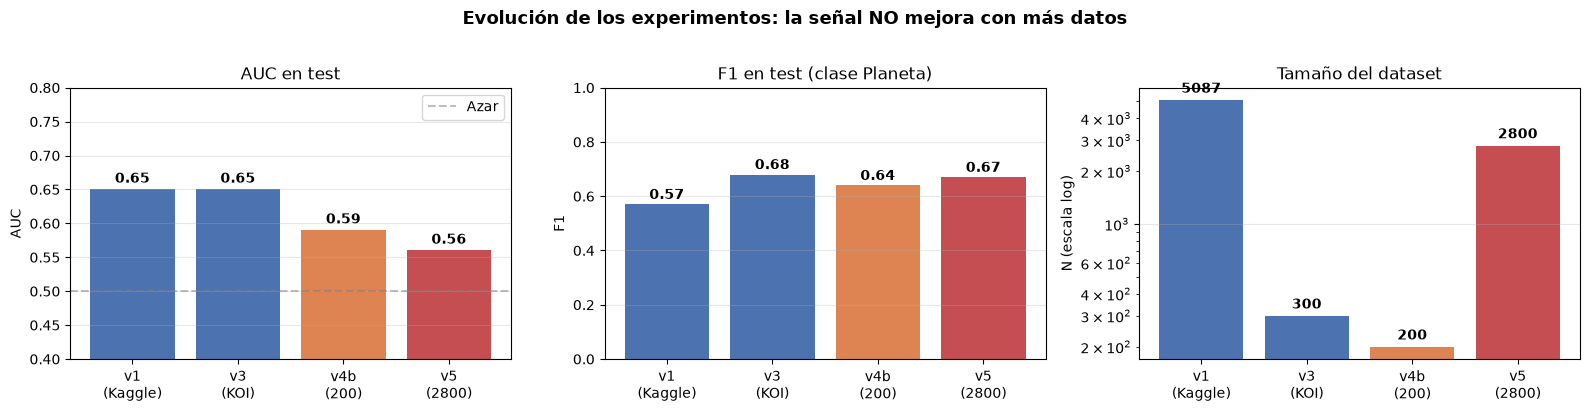

[OK] Gráfica guardada en ../outputs/resumen_proyecto.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Resumen visual de los 4 experimentos principales
# ============================================================
# Experimentos incluidos:
#   v1 — Kaggle (5087 curvas sintéticas)
#   v3 — KOI (300 curvas reales)
#   v4b — 200 curvas reales (100 CONFIRMED + 100 Sin KOI)
#   v5 — 2800 curvas reales (1200 CONFIRMED + 1200 Sin KOI)
#
# Métricas:
#   - AUC en test
#   - F1 en test (clase Planeta)
#   - Tamaño del dataset (escala log)
#
# Objetivo:
#   Visualizar cómo evoluciona el desempeño del modelo
#   conforme aumenta el tamaño y realismo del dataset.
#
# Resultado clave:
#   ❗ La señal NO mejora con más datos reales.
#   ❗ AUC cae de 0.65 → 0.56 al pasar de v1/v3 a v5.
#   ❗ F1 se mantiene alrededor de 0.64–0.68.
#
# Interpretación:
#   - Los tránsitos reales son extremadamente débiles.
#   - El ruido instrumental domina.
#   - El modelo no logra extraer una señal planetaria clara.
# ============================================================

# Datos de los 4 experimentos
experimentos = ['v1\n(Kaggle)', 'v3\n(KOI)', 'v4b\n(200)', 'v5\n(2800)']
aucs = [0.65, 0.65, 0.59, 0.56]
f1s  = [0.57, 0.68, 0.64, 0.67]
ns   = [5087, 300, 200, 2800]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ------------------------------------------------------------
# 1. AUC
# ------------------------------------------------------------
axes[0].bar(experimentos, aucs, color=['#4C72B0', '#4C72B0', '#DD8452', '#C44E52'])
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Azar')
axes[0].set_title('AUC en test')
axes[0].set_ylabel('AUC')
axes[0].set_ylim(0.4, 0.8)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

# ------------------------------------------------------------
# 2. F1 (clase Planeta)
# ------------------------------------------------------------
axes[1].bar(experimentos, f1s, color=['#4C72B0', '#4C72B0', '#DD8452', '#C44E52'])
axes[1].set_title('F1 en test (clase Planeta)')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# ------------------------------------------------------------
# 3. Tamaño del dataset (escala log)
# ------------------------------------------------------------
axes[2].bar(experimentos, ns, color=['#4C72B0', '#4C72B0', '#DD8452', '#C44E52'])
axes[2].set_title('Tamaño del dataset')
axes[2].set_ylabel('N (escala log)')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(ns):
    axes[2].text(i, v * 1.1, str(v), ha='center', fontweight='bold')

# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------
plt.suptitle(
    'Evolución de los experimentos: la señal NO mejora con más datos',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig('../outputs/resumen_proyecto.png', dpi=120, bbox_inches='tight')
plt.show()

print("[OK] Gráfica guardada en ../outputs/resumen_proyecto.png")



In [3]:
import os

archivos = [
    '../README.md',
    '../outputs/proyecto_resultados.json',
    '../outputs/v5_resultados.json',
    '../outputs/resumen_proyecto.png',
]

for a in archivos:
    if os.path.exists(a):
        size = os.path.getsize(a)
        print(f"[OK] {a}  ({size/1024:.1f} KB)")
    else:
        print(f"[FALTA] {a}")


[OK] ../README.md  (0.0 KB)
[OK] ../outputs/proyecto_resultados.json  (3.0 KB)
[OK] ../outputs/v5_resultados.json  (0.9 KB)
[OK] ../outputs/resumen_proyecto.png  (69.7 KB)
